# Network Analysis


This notebook provides a network science analysis of the Drosophila connectome using the FlyWire dataset.

The goal of this notebook is to progressively build a complete structural
understanding of the connectome, starting from basic graph definitions and
ending at pre–community-detection analyses.


## Dataset Overview

- Nodes represent individual neurons.
- Directed edges represent synaptic connections from presynaptic to postsynaptic neurons.
- Edge weights correspond to synapse counts.
- The resulting graph is a large-scale, directed, weighted biological network.

## Analysis Roadmap

### 1. Network Construction

- Load the FlyWire Full Adult Fly Brain Drosophila melanogaster connectome
- Construct a directed, weighted graph representation
- Validate graph integrity

### 2. Basic Network Properties

- Number of nodes and edges
- Network density
- Weakly and strongly connected components
- Size of the giant connected component

### 3. Degree and Strength Analysis

- In-degree and out-degree distributions
- Weighted degree (node strength) distributions
- Functional interpretation of input vs output neurons

### 4. Higher-Order Structural Properties

- Clustering coefficient
- Average shortest path length
- Local vs global connectivity patterns

### 5. Centrality Measures

- In-degree and out-degree centrality
- Betweenness centrality (information bottlenecks)
- Eigenvector centrality / PageRank
- Identification of structurally important neurons

### 6. Random Graph and Null Model Comparison

- Construction of degree-preserving random graphs
- Comparison of clustering, path length, and degree statistics

---


connections_princeton.csv → defines the graph topology

classification.csv → defines attributes of nodes


In [6]:
## Imports and Visualization Settings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from pathlib import Path
from sklearn.cluster import KMeans
from matplotlib.gridspec import GridSpec
import copy

sns.set_context('talk')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlepad'] = 12


## 1) Network Construction


In [7]:
DATA_DIR = Path('../data/raw')
CONNECTIONS_PATH = DATA_DIR / 'connections_princeton.csv'
ANNOTATIONS_PATH = DATA_DIR / 'classification.csv.gz'

EDGE_WEIGHT_COL = 'syn_count'

assert CONNECTIONS_PATH.exists(), 'connections_princeton.csv missing'
CONNECTIONS_PATH
assert ANNOTATIONS_PATH.exists(), 'classification.csv.gz missing'
ANNOTATIONS_PATH
MIN_SYN = 5

In [8]:
connections = pd.read_csv(CONNECTIONS_PATH)
connections = connections[['pre_root_id', 'post_root_id', EDGE_WEIGHT_COL, 'neuropil', 'nt_type']]
connections.head()


,pre_root_id,post_root_id,syn_count,neuropil,nt_type
0,720575940625363947,720575940623224444,12,ME_L,GABA
1,720575940630432382,720575940618518557,67,ME_L,ACH
2,720575940627314521,720575940626337738,10,ME_L,GABA
3,720575940620280405,720575940620204726,15,ME_L,ACH
4,720575940636942447,720575940613789411,1,LA_L,GLUT


In [9]:
# Load classification file
annotations_df = pd.read_csv(ANNOTATIONS_PATH, compression="gzip")

annotations_df.head(3)


,root_id,flow,super_class,class,sub_class,hemilineage,side,nerve
0,720575940599457990,intrinsic,optic,optic_lobe_intrinsic,t4_neuron,NaN,right,NaN
1,720575940599763910,intrinsic,optic,optic_lobe_intrinsic,t5_neuron,NaN,right,NaN
2,720575940600623020,intrinsic,optic,optic_lobe_intrinsic,distal_medulla,NaN,right,NaN


In [10]:
ann = pd.read_csv(ANNOTATIONS_PATH)  
ann.columns = [c.strip() for c in ann.columns]

# what columns exist
print("Annotation columns:", ann.columns.tolist())

# Search for strings to learn the exact naming used in the file
def show_matches(col, pattern, max_show=30):
    if col not in ann.columns: 
        return
    vals = ann[col].dropna().astype(str)
    hits = sorted(set([v for v in vals.unique() if pattern.lower() in v.lower()]))
    print(f"\nMatches for '{pattern}' in {col} ({len(hits)}):")
    print(hits[:max_show])

for col in ["class", "sub_class"]:
    show_matches(col, "MBON")
    show_matches(col, "Kenyon")
    show_matches(col, "KC")
    show_matches(col, "PN")

Annotation columns: ['root_id', 'flow', 'super_class', 'class', 'sub_class', 'hemilineage', 'side', 'nerve']

Matches for 'MBON' in class (1):
['MBON']

Matches for 'Kenyon' in class (1):
['Kenyon_Cell']

Matches for 'KC' in class (0):
[]

Matches for 'PN' in class (2):
['ALPN', 'TPN']

Matches for 'MBON' in sub_class (0):
[]

Matches for 'Kenyon' in sub_class (0):
[]

Matches for 'KC' in sub_class (0):
[]

Matches for 'PN' in sub_class (1):
['water_PN']


Mushroom Body Output Neurons (MBONs): Neurons that transmit processed signals from the mushroom body to downstream brain regions, thereby influencing learning-dependent decision-making and behavior.

Kenyon Cells (KCs): The principal intrinsic neurons of the mushroom body that receive convergent sensory input and form sparse representations essential for associative learning and memory

Antennal Lobe Projection Neurons (ALPNs): Projection neurons that relay olfactory information from the antennal lobe to higher-order brain centers, including the mushroom body and lateral horn.

Tract Projection Neurons (TPNs / iTPNs): Long-range projection neurons defined by their axonal tract anatomy, transmitting information between distant brain regions; iTPNs denote specific tract subclasses with distinct anatomical routing.

water_PN: A specialized subclass of projection neurons associated with water or humidity-related sensory modalities, conveying this information to downstream brain regions.

Canonical mushroom body pathway:
Projection Neurons (ALPNs / TPNs / water_PN) → Kenyon Cells (KCs) → MBONs → downstream brain regions


### CREATING THE REGION OF INTEREST


This step constructs a biologically grounded region of interest by selecting projection neurons (ALPN and TPN), Kenyon cells, and mushroom body output neurons (MBONs) from the neuron annotation data. Using this node set, all directed synaptic connections whose presynaptic and postsynaptic neurons both belong to the ROI are extracted to form the induced subnetwork. Weak connections are then removed by applying a synapse-count threshold, reducing noise and improving interpretability. To control network size while preserving biologically important structure, the subnetwork is further restricted to the top 1000 neurons ranked by total synaptic strength. Finally, the resulting directed and weighted connectivity is converted into an adjacency matrix for subsequent network analysis.


In [11]:
# 1) Define ROI nodes by anatomy (PNs (ALPN, TPN), Kenyon Cells (KC), MBONs)

pns   = set(ann.loc[ann["class"].isin(["ALPN", "TPN"]), "root_id"].astype(int))
kcs   = set(ann.loc[ann["class"] == "Kenyon_Cell", "root_id"].astype(int))
mbons = set(ann.loc[ann["class"] == "MBON", "root_id"].astype(int))
roi_nodes = pns | kcs | mbons
print(f"PN: {len(pns)}, KC: {len(kcs)}, MBON: {len(mbons)}")
print(f"ROI nodes (before pruning): {len(roi_nodes)}")


# 2) Keeps only edges where both source and target neurons are in the ROI
connections_roi = connections[
    connections["pre_root_id"].isin(roi_nodes) &
    connections["post_root_id"].isin(roi_nodes)
].copy()
print("Edges in ROI (before pruning):", len(connections_roi))


# 3) Remove edges with fewer than 10 synapses
MIN_SYN = 10
connections_roi = connections_roi[connections_roi[EDGE_WEIGHT_COL] >= MIN_SYN].copy()
print("Edges after synapse threshold:", len(connections_roi))

# 4) Keep the top 1000 most connected/important nodes in the ROI
out_strength = connections_roi.groupby("pre_root_id")[EDGE_WEIGHT_COL].sum()
in_strength  = connections_roi.groupby("post_root_id")[EDGE_WEIGHT_COL].sum()
strength = out_strength.add(in_strength, fill_value=0)

MAX_NODES = 1000
keep_nodes = strength.sort_values(ascending=False).head(MAX_NODES).index

connections_roi = connections_roi[
    connections_roi["pre_root_id"].isin(keep_nodes) &
    connections_roi["post_root_id"].isin(keep_nodes)
].copy()

print("Final nodes:", len(keep_nodes))
print("Final edges:", len(connections_roi))

keep_set = set(keep_nodes)
print("Kept PN:", len(keep_set & pns))
print("Kept KC:", len(keep_set & kcs))
print("Kept MBON:", len(keep_set & mbons))


# =====  build adj from connections_roi =====
node_list = pd.Index(sorted(keep_nodes))
node_to_idx = {n: i for i, n in enumerate(node_list)}

connections_roi["pre_idx"]  = connections_roi["pre_root_id"].map(node_to_idx)
connections_roi["post_idx"] = connections_roi["post_root_id"].map(node_to_idx)

n = len(node_list)
adj = np.zeros((n, n), dtype=float)
for _, row in connections_roi.iterrows():
    adj[int(row["pre_idx"]), int(row["post_idx"])] += row[EDGE_WEIGHT_COL]

print(f'Nodes kept: {n}, edges kept: {len(connections_roi):,}, total synapses: {connections_roi[EDGE_WEIGHT_COL].sum():,}')
adj


PN: 687, KC: 5177, MBON: 96
ROI nodes (before pruning): 5960
Edges in ROI (before pruning): 143943
Edges after synapse threshold: 24583
Final nodes: 1000
Final edges: 5953
Kept PN: 364
Kept KC: 576
Kept MBON: 60
Nodes kept: 1000, edges kept: 5,953, total synapses: 147,590


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(1000, 1000))

## 2. Basic Network Properties (PN–KC–MBON subnetwork)


In [12]:
# Build directed weighted graph
G_roi = nx.DiGraph()

for _, row in connections_roi.iterrows():
    G_roi.add_edge(
        int(row["pre_root_id"]),
        int(row["post_root_id"]),
        weight=row[EDGE_WEIGHT_COL]
    )

# Integrity checks
print("Number of nodes:", G_roi.number_of_nodes())
print("Number of edges:", G_roi.number_of_edges())
print("Self-loops:", nx.number_of_selfloops(G_roi))
print("Density:", nx.density(G_roi))


Number of nodes: 999
Number of edges: 5589
Self-loops: 0
Density: 0.005605806207008612


In [13]:
nodes = set(G_roi.nodes())

n_pn   = len(nodes & pns)
n_kc   = len(nodes & kcs)
n_mbon = len(nodes & mbons)

print("PN nodes:", n_pn)
print("KC nodes:", n_kc)
print("MBON nodes:", n_mbon)
print("Total nodes:", n_pn + n_kc + n_mbon)


PN nodes: 364
KC nodes: 576
MBON nodes: 59
Total nodes: 999


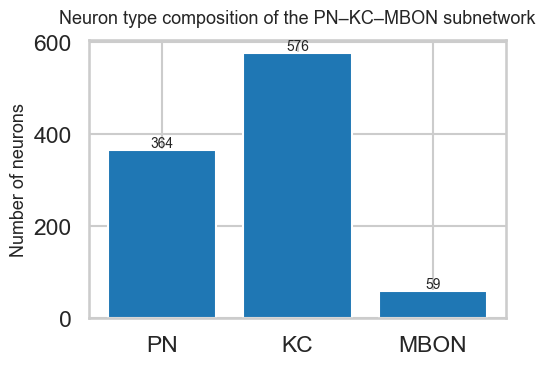

In [18]:
labels = ["PN", "KC", "MBON"]
counts = [n_pn, n_kc, n_mbon]

plt.figure(figsize=(5.5, 4))
bars = plt.bar(labels, counts)

plt.ylabel("Number of neurons", fontsize=13)
plt.title("Neuron type composition of the PN–KC–MBON subnetwork", fontsize=13)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()


In [25]:
# Weakly connected components (ignore direction)
wcc = list(nx.weakly_connected_components(G_roi))
wcc_sizes = [len(c) for c in wcc]

# Strongly connected components (respect direction)
scc = list(nx.strongly_connected_components(G_roi))
scc_sizes = [len(c) for c in scc]

print("Number of weakly connected components:", len(wcc))
print("Largest weakly connected component size:", max(wcc_sizes))

print("Number of strongly connected components:", len(scc))
print("Largest strongly connected component size:", max(scc_sizes))


Number of weakly connected components: 1
Largest weakly connected component size: 999
Number of strongly connected components: 471
Largest strongly connected component size: 497


If we ignore edge direction, all 999 neurons are connected together in a single piece.
There is one giant weakly connected component
Structurally, the PN–KC–MBON subnetwork forms a single connected system.
That single WCC contains all nodes in the graph.
100% of the network belongs to the giant component.
No isolated islands
No disconnected subsystems

When edge direction matters, the network breaks into 471 strongly connected components (SCCs).An SCC is a set of nodes where:
every node can reach every other node following edge directions. The remaining ~500 nodes are in smaller SCCs or single-direction chains. Undirected view:
The network is fully integrated → information can flow somehow between all neurons.

Directed view:
The network is not fully reciprocal → many neurons participate in feed-forward or hierarchical pathways.


In [26]:
print("Fraction in giant WCC:", max(wcc_sizes) / G_roi.number_of_nodes())


Fraction in giant WCC: 1.0


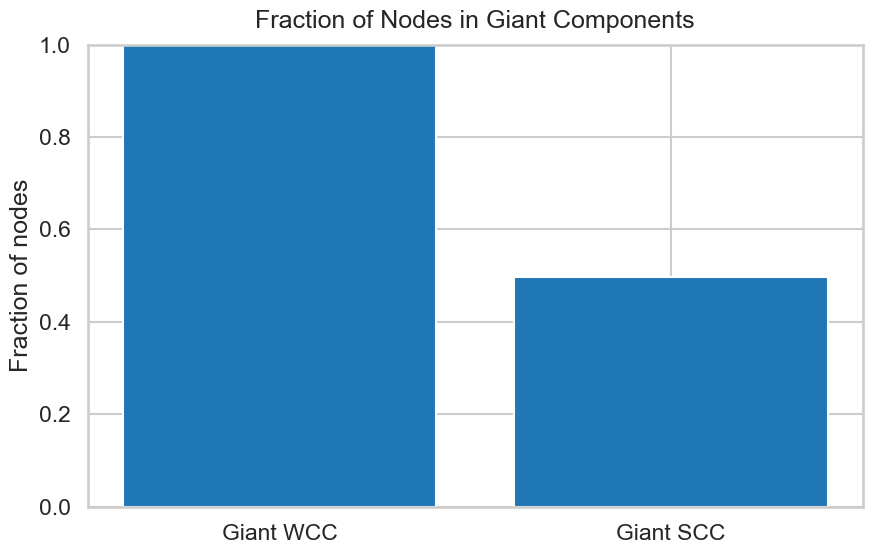

In [30]:
giant_wcc_frac = max(wcc_sizes) / G_roi.number_of_nodes()
giant_scc_frac = max(scc_sizes) / G_roi.number_of_nodes()

plt.figure()
plt.bar(
    ["Giant WCC", "Giant SCC"],
    [giant_wcc_frac, giant_scc_frac]
)
plt.ylim(0, 1)
plt.ylabel("Fraction of nodes")
plt.title("Fraction of Nodes in Giant Components")
plt.show()


This plot is a visual summary of how connected our sub-network is, with and without respecting edge direction.


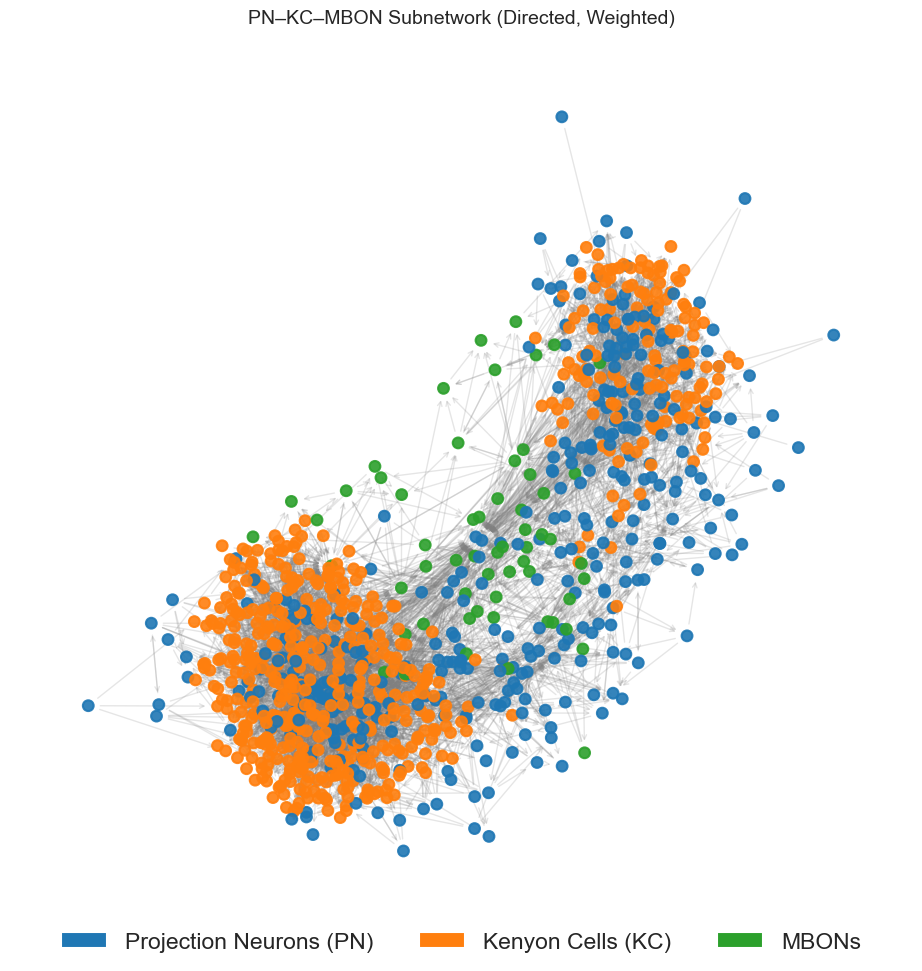

In [127]:
from matplotlib.patches import Patch

# Color nodes by biological class
color_map = []
for n in G_roi.nodes():
    if n in pns:
        color_map.append("tab:blue")     # PN
    elif n in kcs:
        color_map.append("tab:orange")   # KC
    elif n in mbons:
        color_map.append("tab:green")    # MBON
    else:
        color_map.append("gray")

# Layout
pos = nx.spring_layout(G_roi, seed=42)

plt.figure(figsize=(10, 10))

# Draw nodes
nx.draw_networkx_nodes(
    G_roi,
    pos,
    node_color=color_map,
    node_size=60,
    alpha=0.9
)

# Draw edges
nx.draw_networkx_edges(
    G_roi,
    pos,
    arrowstyle="->",
    arrowsize=8,
    edge_color="gray",
    alpha=0.2
)

# ---- Legend ----
legend_elements = [
    Patch(facecolor="tab:blue", label="Projection Neurons (PN)"),
    Patch(facecolor="tab:orange", label="Kenyon Cells (KC)"),
    Patch(facecolor="tab:green", label="MBONs"),
]

plt.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=3,
    frameon=False
)


plt.title("PN–KC–MBON Subnetwork (Directed, Weighted)", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()


## 3. Degree and Strength Analysis


In [46]:
# In-degree and out-degree dictionaries
in_deg  = dict(G_roi.in_degree())
out_deg = dict(G_roi.out_degree())

# Convert to lists
in_vals  = list(in_deg.values())
out_vals = list(out_deg.values())

print("IN-DEGREE STATISTICS")
print(f"  Average in-degree: {np.mean(in_vals):.2f}")
print(f"  Max in-degree:     {np.max(in_vals)}")
print(f"  Min in-degree:     {np.min(in_vals)}")

print("\nOUT-DEGREE STATISTICS")
print(f"  Average out-degree: {np.mean(out_vals):.2f}")
print(f"  Max out-degree:     {np.max(out_vals)}")
print(f"  Min out-degree:     {np.min(out_vals)}")


IN-DEGREE STATISTICS
  Average in-degree: 5.59
  Max in-degree:     112
  Min in-degree:     0

OUT-DEGREE STATISTICS
  Average out-degree: 5.59
  Max out-degree:     114
  Min out-degree:     0


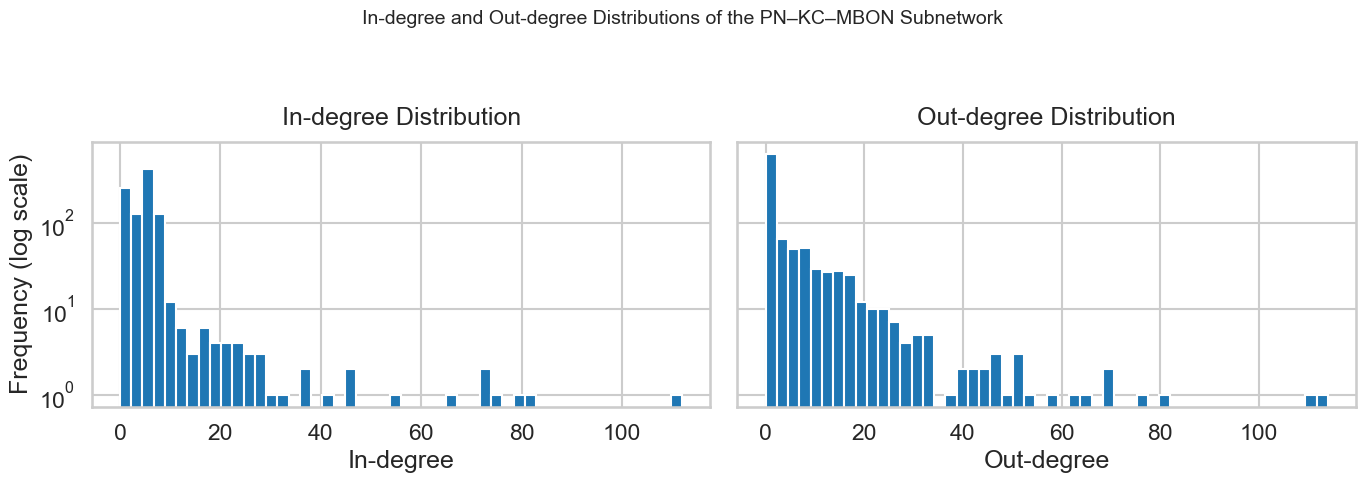

In [38]:
# In-degree and out-degree
in_deg  = dict(G_roi.in_degree())
out_deg = dict(G_roi.out_degree())

in_vals  = list(in_deg.values())
out_vals = list(out_deg.values())

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# In-degree distribution
axes[0].hist(in_vals, bins=50)
axes[0].set_yscale("log")
axes[0].set_xlabel("In-degree")
axes[0].set_ylabel("Frequency (log scale)")
axes[0].set_title("In-degree Distribution")

# Out-degree distribution
axes[1].hist(out_vals, bins=50)
axes[1].set_yscale("log")
axes[1].set_xlabel("Out-degree")
axes[1].set_title("Out-degree Distribution")

# Overall title
fig.suptitle(
    "In-degree and Out-degree Distributions of the PN–KC–MBON Subnetwork",
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()



In [47]:
# Weighted in-degree and out-degree (node strength)
in_strength  = dict(G_roi.in_degree(weight="weight"))
out_strength = dict(G_roi.out_degree(weight="weight"))

# Convert to lists
in_s_vals  = list(in_strength.values())
out_s_vals = list(out_strength.values())

print("IN-STRENGTH STATISTICS (weighted)")
print(f"  Average in-strength: {np.mean(in_s_vals):.2f}")
print(f"  Max in-strength:     {np.max(in_s_vals)}")
print(f"  Min in-strength:     {np.min(in_s_vals)}")

print("\nOUT-STRENGTH STATISTICS (weighted)")
print(f"  Average out-strength: {np.mean(out_s_vals):.2f}")
print(f"  Max out-strength:     {np.max(out_s_vals)}")
print(f"  Min out-strength:     {np.min(out_s_vals)}")


IN-STRENGTH STATISTICS (weighted)
  Average in-strength: 134.27
  Max in-strength:     2342
  Min in-strength:     0

OUT-STRENGTH STATISTICS (weighted)
  Average out-strength: 134.27
  Max out-strength:     3741
  Min out-strength:     0


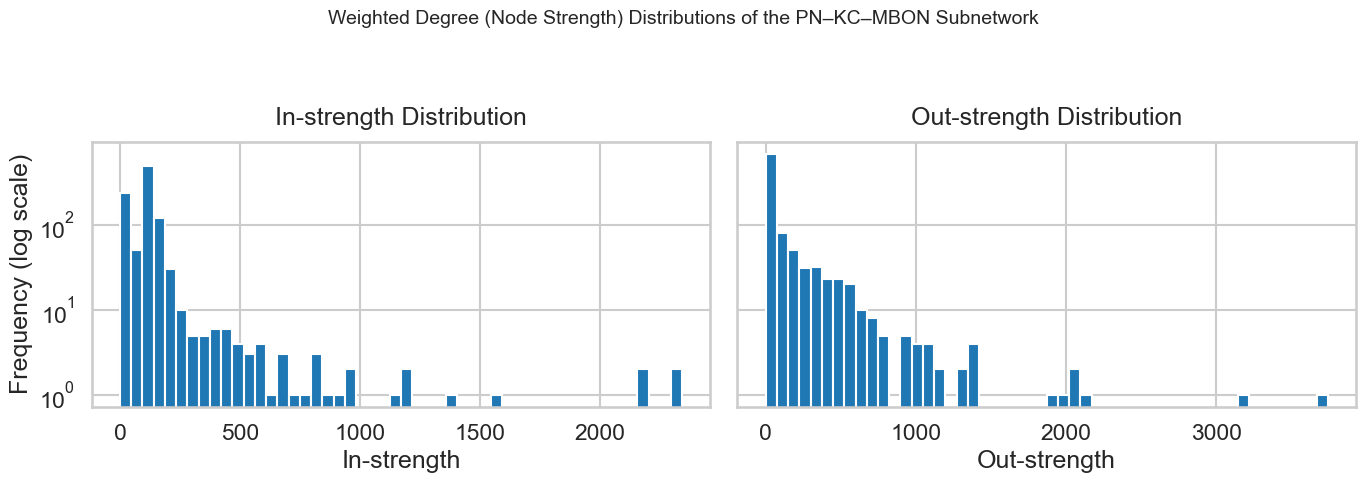

In [40]:
# Node strength (weighted degree)
in_strength  = dict(G_roi.in_degree(weight="weight"))
out_strength = dict(G_roi.out_degree(weight="weight"))

in_s_vals  = list(in_strength.values())
out_s_vals = list(out_strength.values())

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# In-strength distribution
axes[0].hist(in_s_vals, bins=50)
axes[0].set_yscale("log")
axes[0].set_xlabel("In-strength")
axes[0].set_ylabel("Frequency (log scale)")
axes[0].set_title("In-strength Distribution")

# Out-strength distribution
axes[1].hist(out_s_vals, bins=50)
axes[1].set_yscale("log")
axes[1].set_xlabel("Out-strength")
axes[1].set_title("Out-strength Distribution")

# Overall title
fig.suptitle(
    "Weighted Degree (Node Strength) Distributions of the PN–KC–MBON Subnetwork",
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


Both distributions are heavy-tailed

Most neurons have low in-strength and out-strength

A small number of neurons have very large synaptic strength

This indicates a hub-dominated organization, not a uniform network

The PN–KC–MBON subnetwork is highly heterogeneous, with a few neurons dominating synaptic traffic.


In [36]:
out_strength = adj.sum(axis=1)   # sum of outgoing weights
in_strength  = adj.sum(axis=0)   # sum of incoming weights
df_strength = pd.DataFrame({
    "out_strength": out_strength,
    "in_strength": in_strength,
    "node": node_list
})

def node_type(n):
    if n in pns: return "PN"
    if n in kcs: return "KC"
    if n in mbons: return "MBON"
    return "Other"

df_strength["type"] = df_strength["node"].map(node_type)


In [37]:
# Averages by type
df_strength.groupby("type")[["out_strength", "in_strength"]].mean()


,out_strength,in_strength
type,,
KC,11.611111,126.590278
MBON,318.833333,431.266667
PN,334.538462,134.060440


- KCs act as integrators, combining input from many neurons before passing sparse signals onward.
- MBONs function as decision and control units, integrating information and broadcasting behavioral commands.
- PNs act primarily as information broadcasters, carrying sensory signals to downstream layers.


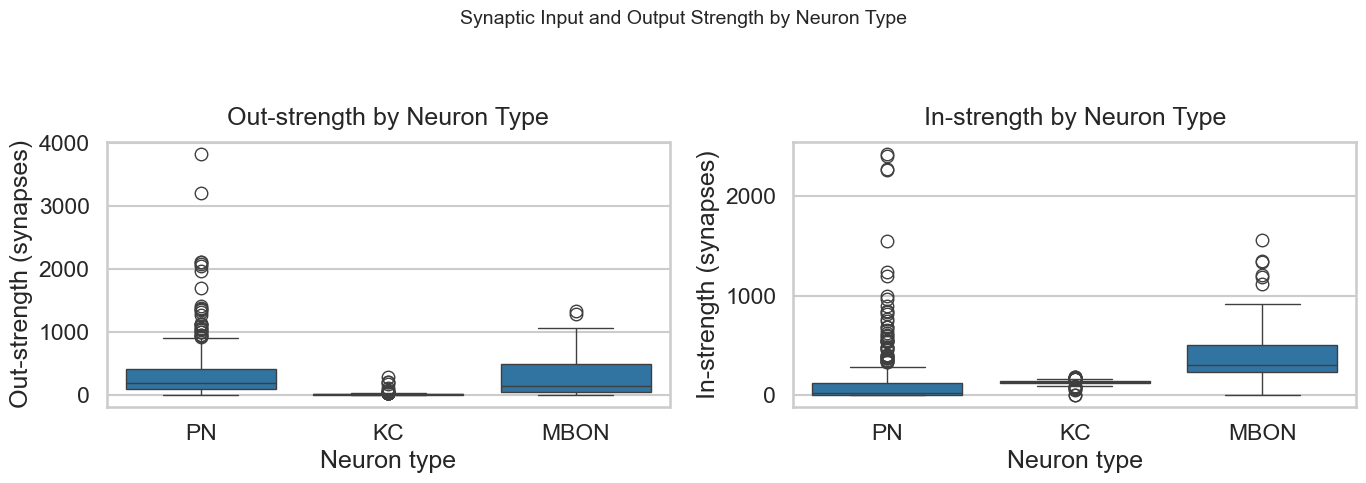

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

# Out-strength boxplot
sns.boxplot(
    data=df_strength,
    x="type",
    y="out_strength",
    ax=axes[0]
)
axes[0].set_title("Out-strength by Neuron Type")
axes[0].set_xlabel("Neuron type")
axes[0].set_ylabel("Out-strength (synapses)")

# In-strength boxplot
sns.boxplot(
    data=df_strength,
    x="type",
    y="in_strength",
    ax=axes[1]
)
axes[1].set_title("In-strength by Neuron Type")
axes[1].set_xlabel("Neuron type")
axes[1].set_ylabel("In-strength (synapses)")

# Overall title
fig.suptitle(
    "Synaptic Input and Output Strength by Neuron Type",
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


## 4. Higher-Order Structural Properties

#### (How clustered and how efficiently connected is the network?)


Local connectivity

“If neuron A connects to B and C, do B and C also connect to each other?”


In [49]:
# Convert to undirected graph
G_und = G_roi.to_undirected()
avg_clustering = nx.average_clustering(G_und)
print(f"Average clustering coefficient: {avg_clustering:.4f}")



Average clustering coefficient: 0.0740


On average, only ~7.4% of a neuron’s neighbors are also connected to each other.


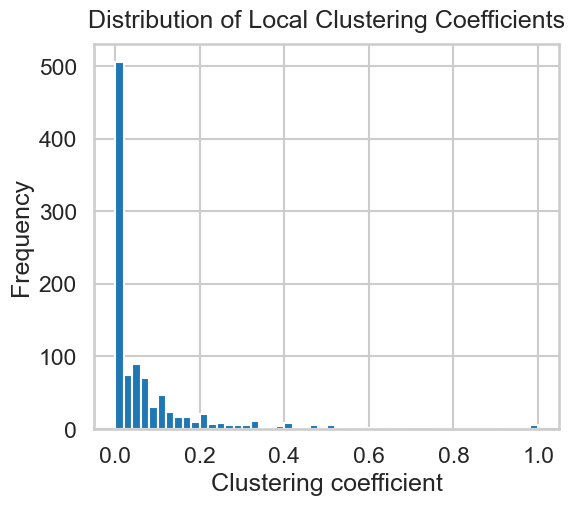

In [50]:
“For each neuron, how interconnected are its neighbors with each other?”

This pilot shows for each neuron, how interconnected are its neighbors with each other?

- 0 → none of the neightbours connect
- 1 → all of the negihbours connect (tight clique)


#### Average Shortest Path Length

“On average, how many steps does it take to go from one neuron to another?”

Short paths = efficient communication


In [53]:
# Giant weakly connected component
wcc = max(nx.weakly_connected_components(G_roi), key=len)
G_wcc = G_roi.subgraph(wcc)

# Convert to undirected for path length
G_wcc_und = G_wcc.to_undirected()
avg_path_len = nx.average_shortest_path_length(G_wcc_und)
print(f"Average shortest path length: {avg_path_len:.3f}")



Average shortest path length: 3.298


Small (~3–6) → small-world-like efficiency


In [57]:
# We compute average shortest path on the largest connected component within each group.
def avg_path_length_largest_cc(G):
    if len(G) == 0:
        return None
    # take largest connected component
    cc = max(nx.connected_components(G), key=len)
    G_cc = G.subgraph(cc)
    if G_cc.number_of_nodes() < 2:
        return None
    return nx.average_shortest_path_length(G_cc)
results = {}

for name, nodes in {
    "PN": pns,
    "KC": kcs,
    "MBON": mbons
}.items():
    sub = G_wcc_und.subgraph(nodes)
    apl = avg_path_length_largest_cc(sub)
    results[name] = apl
    print(f"{name}: average path length = {apl}")



PN: average path length = 3.2608425016728653
KC: average path length = 1.0
MBON: average path length = 2.3500876680303917


Average shortest path lengths computed within neuron-type subgraphs reveal distinct organizational principles. PN's exhibit longer internal paths, consistent with sparse broadcast connectivity. KC's form highly compact local components with minimal path lengths, reflecting localized integration motifs. MBON's display intermediate path lengths, consistent with convergent readout structure.


### 5. Centrality Measures


##### In-degree & Out-degree Centrality

(Who receives a lot? Who broadcasts a lot?)

- High in-degree → receiver / integrator
- High out-degree → broadcaster / influencer


In [85]:
def node_group(n):
    if n in pns:
        return "PN"
    if n in kcs:
        return "KC"
    if n in mbons:
        return "MBON"
    return "Other"

in_deg_cent  = nx.in_degree_centrality(G_roi)
out_deg_cent = nx.out_degree_centrality(G_roi)
def top_k(d, k=10):
    return sorted(d.items(), key=lambda x: x[1], reverse=True)[:k]

print("Top in-degree centrality:")
for node, val in top_k(in_deg_cent):
    print(f"Node: {node}; in-degree centrality: {val:.3f};  group: {node_group(node)} ")





Top in-degree centrality:
Node: 720575940630496374; in-degree centrality: 0.112;  group: MBON 
Node: 720575940638028607; in-degree centrality: 0.081;  group: MBON 
Node: 720575940640372021; in-degree centrality: 0.080;  group: PN 
Node: 720575940627129290; in-degree centrality: 0.074;  group: PN 
Node: 720575940608124338; in-degree centrality: 0.073;  group: PN 
Node: 720575940631630021; in-degree centrality: 0.073;  group: PN 
Node: 720575940661114753; in-degree centrality: 0.066;  group: PN 
Node: 720575940614238114; in-degree centrality: 0.056;  group: PN 
Node: 720575940621164720; in-degree centrality: 0.047;  group: MBON 
Node: 720575940629422086; in-degree centrality: 0.045;  group: MBON 


In [82]:

print("\nTop out-degree centrality:")
for node, val in top_k(out_deg_cent):
    print(f"Node {node}  out-degree centrality: {val:.3f} group: {node_group(node)}")



Top out-degree centrality:
Node 720575940630770042  out-degree centrality: 0.114 group: PN
Node 720575940618308825  out-degree centrality: 0.111 group: PN
Node 720575940637056887  out-degree centrality: 0.080 group: PN
Node 720575940648650884  out-degree centrality: 0.076 group: PN
Node 720575940611079236  out-degree centrality: 0.070 group: PN
Node 720575940623528925  out-degree centrality: 0.069 group: PN
Node 720575940619071005  out-degree centrality: 0.064 group: PN
Node 720575940628467611  out-degree centrality: 0.062 group: PN
Node 720575940617668747  out-degree centrality: 0.059 group: PN
Node 720575940618295454  out-degree centrality: 0.054 group: PN


##### Betweenness Centrality

Betweenness centrality measures how often a neuron lies on the shortest paths between other neurons.
(Who is a bottleneck?)

High betweenness = information gatekeeper


In [88]:
bet_cent = nx.betweenness_centrality(G_roi, normalized=True)
print("Top betweenness centrality:")
for node, val in top_k(bet_cent):
    print(
        f"Node: {node}, "
        f"betweenness: {val:.3f}, "
        f"group: {node_group(node)}, "
     
    )


Top betweenness centrality:
Node: 720575940626507834, betweenness: 0.117, group: PN, 
Node: 720575940617567206, betweenness: 0.116, group: MBON, 
Node: 720575940630770042, betweenness: 0.112, group: PN, 
Node: 720575940623547133, betweenness: 0.107, group: PN, 
Node: 720575940638028607, betweenness: 0.093, group: MBON, 
Node: 720575940622334448, betweenness: 0.089, group: PN, 
Node: 720575940614238114, betweenness: 0.088, group: PN, 
Node: 720575940623201833, betweenness: 0.084, group: MBON, 
Node: 720575940621776161, betweenness: 0.081, group: PN, 
Node: 720575940626675837, betweenness: 0.071, group: PN, 


##### Eigenvector Centrality / PageRank

“Which neurons are important because they are connected to other important neurons?”

Eigenvector centrality can be unstable in directed graphs, so we used: Pagerank


In [64]:
df_cent = pd.DataFrame({
    "node": list(G_roi.nodes()),
    "in_deg_cent": pd.Series(in_deg_cent),
    "out_deg_cent": pd.Series(out_deg_cent),
    "betweenness": pd.Series(bet_cent),
    "pagerank": pd.Series(pagerank),
})

def node_type(n):
    if n in pns: return "PN"
    if n in kcs: return "KC"
    if n in mbons: return "MBON"
    return "Other"

df_cent["type"] = df_cent["node"].map(node_type)


In [91]:
print("Top PageRank neurons:")
df_cent.sort_values("pagerank", ascending=False).head(10)


Top PageRank neurons:


,node,in_deg_cent,out_deg_cent,betweenness,pagerank,type
720575940629981440,720575940629981440,0.013026,0.002004,0.000021,0.042272,MBON
720575940607155890,720575940607155890,0.016032,0.001002,0.000023,0.038072,MBON
720575940638028607,720575940638028607,0.081162,0.010020,0.093402,0.035721,MBON
720575940630496374,720575940630496374,0.112224,0.007014,0.064641,0.030798,MBON
720575940631177803,720575940631177803,0.012024,0.000000,0.000000,0.023140,MBON
720575940618008859,720575940618008859,0.007014,0.011022,0.005409,0.020887,MBON
720575940623201833,720575940623201833,0.041082,0.017034,0.083542,0.019618,MBON
720575940617749538,720575940617749538,0.030060,0.020040,0.052547,0.018160,MBON
720575940614026193,720575940614026193,0.016032,0.004008,0.007744,0.015502,MBON
720575940621164720,720575940621164720,0.047094,0.008016,0.027230,0.013801,MBON


In [67]:
df_cent.groupby("type")[["in_deg_cent", "out_deg_cent"]].mean()


,in_deg_cent,out_deg_cent
type,,
KC,0.005504,0.000882
MBON,0.013400,0.004959
PN,0.004504,0.013186


In [69]:
#who is important
df_cent.groupby("type")[["betweenness", "pagerank"]].mean()


,betweenness,pagerank
type,,
KC,0.000081,0.000380
MBON,0.017663,0.009186
PN,0.005037,0.000656


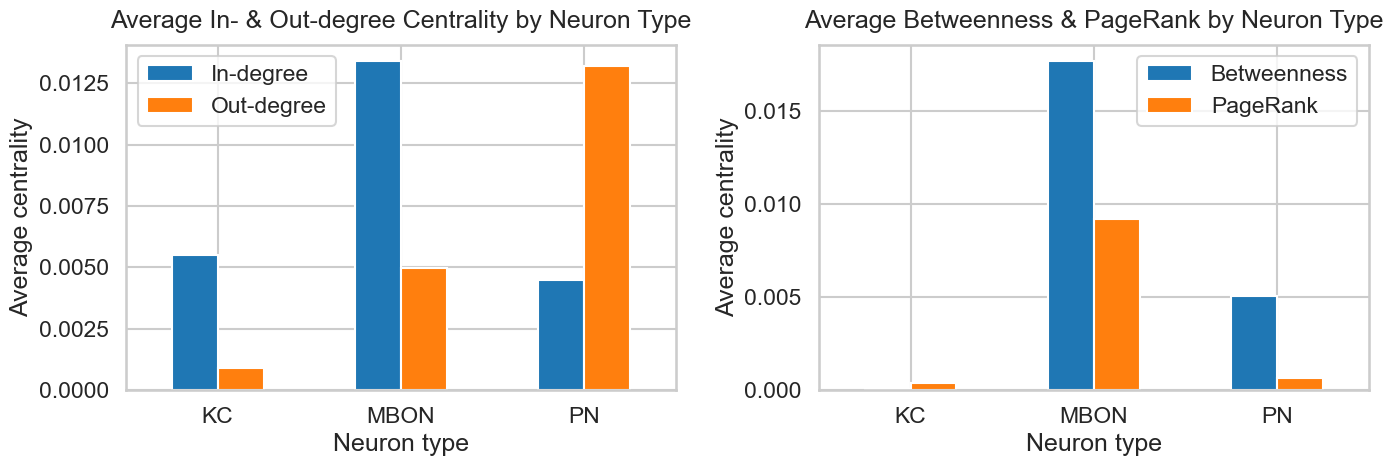

In [93]:
import matplotlib.pyplot as plt

# Compute group averages
deg_means = df_cent.groupby("type")[["in_deg_cent", "out_deg_cent"]].mean()
imp_means = df_cent.groupby("type")[["betweenness", "pagerank"]].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: In / Out degree centrality ---
deg_means.plot(
    kind="bar",
    ax=axes[0]
)
axes[0].set_title("Average In- & Out-degree Centrality by Neuron Type")
axes[0].set_ylabel("Average centrality")
axes[0].set_xlabel("Neuron type")
axes[0].legend(["In-degree", "Out-degree"])
axes[0].tick_params(axis="x", rotation=0)

# --- Plot 2: Betweenness / PageRank ---
imp_means.plot(
    kind="bar",
    ax=axes[1]
)
axes[1].set_title("Average Betweenness & PageRank by Neuron Type")
axes[1].set_ylabel("Average centrality")
axes[1].set_xlabel("Neuron type")
axes[1].legend(["Betweenness", "PageRank"])
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


Centrality analysis shows a clear functional separation: projection neurons primarily broadcast information, Kenyon cells act as local integrators, and MBONs emerge as globally central decision and bottleneck nodes.


#### Is the network fragile or robust to targeted attacks?

If we remove the most important neurons, does the network fall apart or stay connected?


In [94]:
def giant_wcc_fraction(G):
    wcc = max(nx.weakly_connected_components(G), key=len)
    return len(wcc) / G.number_of_nodes()
#Compute  the fraction of nodes that still belong to giant component
baseline_frac = giant_wcc_fraction(G_roi)
print("Baseline giant WCC fraction:", baseline_frac)


Baseline giant WCC fraction: 1.0


In [71]:
#Remove top-k important neurons (PageRank)
def remove_top_k(G, scores, k):
    top_nodes = sorted(scores, key=scores.get, reverse=True)[:k]
    G_new = G.copy()
    G_new.remove_nodes_from(top_nodes)
    return G_new


In [72]:
#Attacking the network step by step
ks = [5, 10, 20, 50, 100]
fractions = []

for k in ks:
    G_removed = remove_top_k(G_roi, pagerank, k)
    frac = giant_wcc_fraction(G_removed)
    fractions.append(frac)
    print(f"Removed top {k} nodes → giant WCC fraction = {frac:.3f}")


Removed top 5 nodes → giant WCC fraction = 1.000
Removed top 10 nodes → giant WCC fraction = 1.000
Removed top 20 nodes → giant WCC fraction = 1.000
Removed top 50 nodes → giant WCC fraction = 0.999
Removed top 100 nodes → giant WCC fraction = 0.991


Even after removing 100 most important neurons: 99.1% of nodes are still connected

Connectivity barely changes, the network is highly robust to targeted attacks


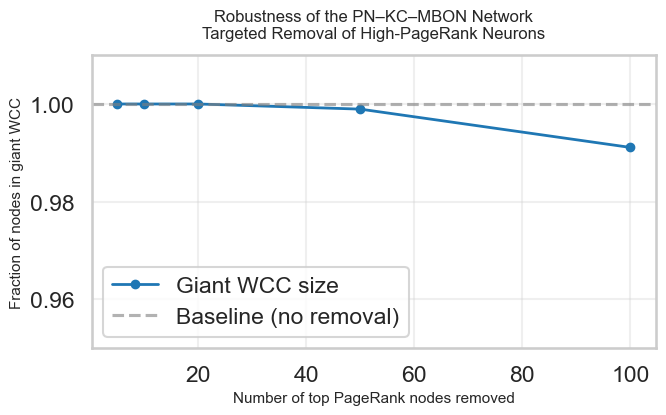

In [97]:
plt.figure(figsize=(7,4.5))

plt.plot(
    ks,
    fractions,
    marker="o",
    linewidth=2,
    markersize=6,
    label="Giant WCC size"
)

plt.axhline(
    y=baseline_frac,
    linestyle="--",
    color="gray",
    alpha=0.6,
    label="Baseline (no removal)"
)

plt.xlabel("Number of top PageRank nodes removed", fontsize=11)
plt.ylabel("Fraction of nodes in giant WCC", fontsize=11)
plt.title("Robustness of the PN–KC–MBON Network\nTargeted Removal of High-PageRank Neurons",
          fontsize=12)

plt.ylim(0.95, 1.01)  
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### 6. Random Graph and Null Model Comparison

We check whether the structure we observe in the PN–KC–MBON network is non-trivial or could arise by chance


A null model is a randomized version of the network that preserves some basic properties (like degree), but destroys higher-order structure.

Degree-preserving random graphs => We want to randomize who connects to whom


In [ ]:
# We use undirected version for null model comparisons
G_und = G_roi.to_undirected()


In [115]:
#Creating degree-preserving random graphs
def degree_preserving_random_graph(G, n_swaps=10):
    G_rand = copy.deepcopy(G)
    nx.double_edge_swap(
        G_rand,
        nswap=n_swaps * G.number_of_edges(),
        max_tries=n_swaps * G.number_of_edges() * 10
    )
    return G_rand


In [116]:
real_clustering = nx.average_clustering(G_und)
real_path_len = nx.average_shortest_path_length(G_und)

print("Real network:")
print("Average clustering:", real_clustering)
print("Average path length:", real_path_len)


Real network:
Average clustering: 0.07396073201534002
Average path length: 3.2983765328454706


In [117]:
n_random = 10  
rand_clustering = []
rand_path_len = []

for i in range(n_random):
    G_rand = degree_preserving_random_graph(G_und)
    rand_clustering.append(nx.average_clustering(G_rand))
    rand_path_len.append(nx.average_shortest_path_length(G_rand))


In [118]:
print("Random graphs (mean ± std):")
print(f"Clustering: {np.mean(rand_clustering):.4f} ± {np.std(rand_clustering):.4f}")
print(f"Path length: {np.mean(rand_path_len):.4f} ± {np.std(rand_path_len):.4f}")


Random graphs (mean ± std):
Clustering: 0.0530 ± 0.0014
Path length: 2.9070 ± 0.0053


We compared the PN–KC–MBON subnetwork to degree-preserving random graphs to assess whether its structure deviates from random expectations. While the average shortest path length of the real network (≈3.30) is comparable to that of the randomized networks (≈2.91), the real network exhibits substantially higher clustering (0.074 vs. 0.054 ± 0.002). This indicates the presence of non-random local connectivity patterns beyond what can be explained by degree distribution alone, consistent with a small-world organization that combines efficient global communication with enhanced local clustering.


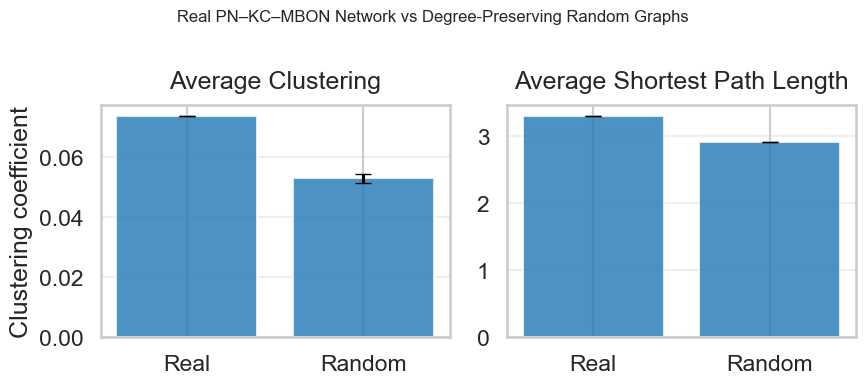

In [119]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Clustering", "Path Length"]

real_vals = [real_clustering, real_path_len]
rand_means = [np.mean(rand_clustering), np.mean(rand_path_len)]
rand_stds  = [np.std(rand_clustering), np.std(rand_path_len)]

x = np.arange(len(metrics))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=False)

axes[0].bar(
    ["Real", "Random"],
    [real_vals[0], rand_means[0]],
    yerr=[0, rand_stds[0]],
    capsize=6,
    alpha=0.8
)
axes[0].set_title("Average Clustering")
axes[0].set_ylabel("Clustering coefficient")
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(
    ["Real", "Random"],
    [real_vals[1], rand_means[1]],
    yerr=[0, rand_stds[1]],
    capsize=6,
    alpha=0.8
)
axes[1].set_title("Average Shortest Path Length")
axes[1].grid(axis="y", alpha=0.3)

fig.suptitle(
    "Real PN–KC–MBON Network vs Degree-Preserving Random Graphs",
    fontsize=12
)

plt.tight_layout()
plt.show()


#### Do directed paths in the PN–KC–MBON subnetwork follow the expected feedforward pattern, and do Kenyon Cells act as intermediates between PN and MBON?


We will check three things:

1. PN → MBON reachability

2. Whether shortest paths go through KC

3. Typical path lengths


In [38]:
pn_nodes   = list(pns & set(G_roi.nodes))
mbon_nodes = list(mbons & set(G_roi.nodes))

reachable_pairs = 0
total_pairs = 0

for pn in pn_nodes:
    reachable = nx.descendants(G_roi, pn)
    for mbon in mbon_nodes:
        total_pairs += 1
        if mbon in reachable:
            reachable_pairs += 1

print("PN → MBON reachable pairs:", reachable_pairs)
print("Total PN–MBON pairs:", total_pairs)
print("Reachability fraction:", reachable_pairs / total_pairs)


PN → MBON reachable pairs: 48222
Total PN–MBON pairs: 65952
Reachability fraction: 0.7311681222707423


This high fraction indicates a directed feedforward backbone


In [39]:
# We measure path length,
path_lengths = []

for pn in pn_nodes:
    for mbon in mbon_nodes:
        if nx.has_path(G_roi, pn, mbon):
            try:
                length = nx.shortest_path_length(G_roi, pn, mbon)
                path_lengths.append(length)
            except nx.NetworkXNoPath:
                pass

pd.Series(path_lengths).describe()


count    48222.000000
mean         3.476525
std          0.979465
min          1.000000
25%          3.000000
50%          3.000000
75%          4.000000
max          9.000000
dtype: float64

Typical path length ≈ 3

This short path support efficient feedforward transmission


#### Do shortest paths pass through KC?


In [41]:
kc_nodes = set(kcs & set(G_roi.nodes))

paths_through_kc = 0
total_paths = 0

for pn in pn_nodes:
    for mbon in mbon_nodes:
        if nx.has_path(G_roi, pn, mbon):
            path = nx.shortest_path(G_roi, pn, mbon)
            total_paths += 1
            if any(node in kc_nodes for node in path[1:-1]):
                paths_through_kc += 1

print("Paths via KC:", paths_through_kc)
print("Total PN → MBON paths:", total_paths)
print("Fraction via KC:", paths_through_kc / total_paths)


Paths via KC: 43934
Total PN → MBON paths: 48222
Fraction via KC: 0.9110779312347062


High fraction means KC nodes are structural intermediates

Confirms the PN → KC → MBON architecture

PN nodes initiate many directed paths

MBON nodes terminate many directed paths

KC nodes lie on a large fraction of shortest paths


### Testing for the presence of a bow-tie structure in the network


In [19]:
#Checking whether the network has a large strongly connected core.
# Strongly connected components
sccs = list(nx.strongly_connected_components(G_roi))

# Largest SCC = core
core = max(sccs, key=len)
core = set(core)

print("Core size:", len(core))


Core size: 497


In [21]:
IN = set()
OUT = set()

for n in G_roi.nodes():
    if n in core:
        continue

    # Can reach core?
    if any(nx.has_path(G_roi, n, c) for c in core):
        IN.add(n)

    # Reachable from core?
    if any(nx.has_path(G_roi, c, n) for c in core):
        OUT.add(n)

# Clean separation
IN -= OUT
OUT -= IN

print("IN size:", len(IN))
print("OUT size:", len(OUT))


IN size: 221
OUT size: 261


In [22]:
TENDRILS = set(G_roi.nodes()) - core - IN - OUT
print("Tendrils size:", len(TENDRILS))


Tendrils size: 20


In [23]:
def count_types(nodeset):
    return {
        "PN": len(nodeset & pns),
        "KC": len(nodeset & kcs),
        "MBON": len(nodeset & mbons)
    }

print("IN:", count_types(IN))
print("CORE:", count_types(core))
print("OUT:", count_types(OUT))
print("TENDRILS:", count_types(TENDRILS))


IN: {'PN': 186, 'KC': 35, 'MBON': 0}
CORE: {'PN': 144, 'KC': 310, 'MBON': 43}
OUT: {'PN': 25, 'KC': 220, 'MBON': 16}
TENDRILS: {'PN': 9, 'KC': 11, 'MBON': 0}


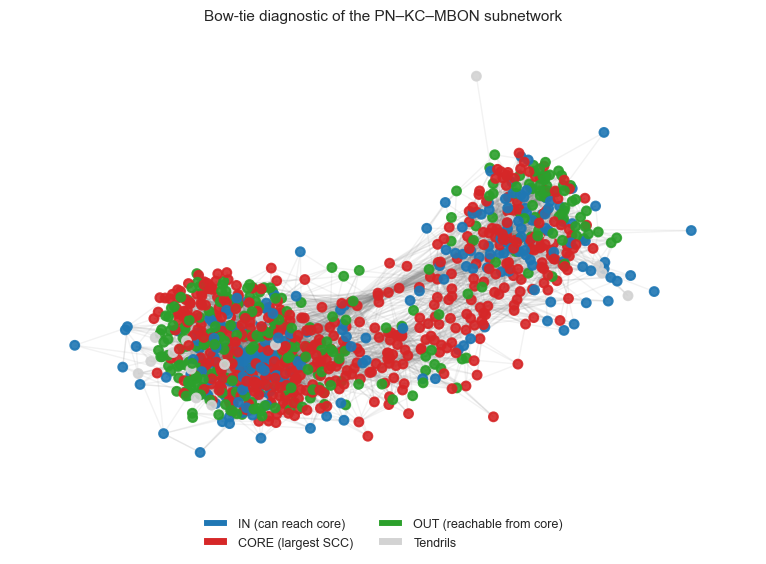

In [25]:
from matplotlib.patches import Patch

color_map = []
for n in G_roi.nodes():
    if n in IN:
        color_map.append("tab:blue")     # IN
    elif n in core:
        color_map.append("tab:red")      # CORE
    elif n in OUT:
        color_map.append("tab:green")    # OUT
    else:
        color_map.append("lightgray")    # TENDRILS

pos = nx.spring_layout(G_roi, seed=42, k=0.25)

plt.figure(figsize=(8, 6))

nx.draw_networkx_nodes(
    G_roi,
    pos,
    node_color=color_map,
    node_size=40,
    alpha=0.9
)

nx.draw_networkx_edges(
    G_roi,
    pos,
    edge_color="gray",
    alpha=0.1,
    arrows=False
)

# ---- Legend ----
legend_elements = [
    Patch(facecolor="tab:blue", label="IN (can reach core)"),
    Patch(facecolor="tab:red", label="CORE (largest SCC)"),
    Patch(facecolor="tab:green", label="OUT (reachable from core)"),
    Patch(facecolor="lightgray", label="Tendrils"),
]

plt.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    frameon=False,
    fontsize=9
)

plt.title("Bow-tie diagnostic of the PN–KC–MBON subnetwork", fontsize=11)
plt.axis("off")
plt.tight_layout()
plt.show()


A bow-tie decomposition of the PN–KC–MBON subnetwork reveals that the largest strongly connected component is small, indicating the absence of a classical bow-tie architecture. While nodes can be partitioned into IN, CORE, OUT, and tendril regions, the core does not constitute a large recurrent backbone. Instead, the majority of neurons participate in directed paths that traverse the network without forming extensive feedback loops.

This result supports the interpretation that the subnetwork is predominantly feedforward and hierarchically organized, consistent with known biological roles of projection neurons as information sources, Kenyon cells as intermediate processors, and mushroom body output neurons as downstream integrators. The lack of a substantial recurrent core suggests that global recurrence is not a defining feature of this circuit, and that information flow is structured primarily along directed pathways rather than through cyclic interactions.
